# **Notebook 7 – Binning & Discretization**

In [22]:
# Load Datset
import pandas as pd
df = pd.read_csv("bank_customer_risk_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   object 
 1   Age                 1000 non-null   int64  
 2   Annual_Income       992 non-null    float64
 3   Credit_Score        994 non-null    float64
 4   Loan_Amount         1000 non-null   float64
 5   Loan_Tenure_Months  1000 non-null   int64  
 6   Debt_to_Income      1000 non-null   float64
 7   Interest_Rate       1000 non-null   float64
 8   Gender              1000 non-null   object 
 9   Employment_Type     995 non-null    object 
 10  Education_Level     1000 non-null   object 
 11  Marital_Status      1000 non-null   object 
 12  Loan_Type           1000 non-null   object 
 13  Loan_Default        1000 non-null   object 
dtypes: float64(5), int64(2), object(7)
memory usage: 109.5+ KB


## **1. What is Binning?**

**Understand the Concept**

* Binning means grouping a continuous numerical values into categories .
* Each group represents a range of values.
* It converts numerical data into categories.

**Demonstrate the Concept**

**Example:**

* Age 18–30 → Young
* Age 31–50 → Adult
* Age 51–70 → Senior

## **2. Why Binning?**

**Understand the Concept**

* Helps handle non-linear relationships.
* Reduces noise in the data.
* Reduces the effect of outliers.
* Makes features easier to understand.
* Creates meaningful categories.

## **3. Equal-Width Binning**

**Understand the Concept**

* Equal-Width Binning divides the values into groups of the same size.
* Every group covers an equal range of values.

**Demonstrate the Concept**

**Example:**

* If Age ranges from 20 to 70, we can create groups of 10 years each.

In [23]:
# Equal-Width Binning
df["Age_Equal_Width"] = pd.cut(df["Age"], bins=5,
                               labels=["Group 1", "Group 2", "Group 3", "Group 4", "Group 5"])
df[["Age", "Age_Equal_Width"]].sample(5)

,Age,Age_Equal_Width
60,37,Group 2
40,41,Group 3
261,59,Group 4
665,21,Group 1
885,36,Group 2


<Axes: xlabel='Age_Equal_Width'>

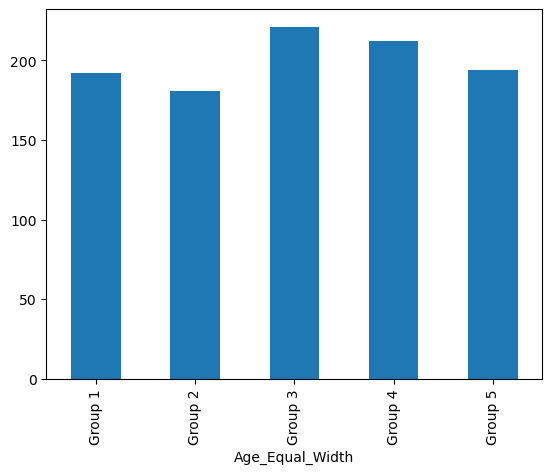

In [24]:
# Bar - Groups range
df["Age_Equal_Width"].value_counts().sort_index().plot(kind="bar")

**Explanation**

* pd.cut() divides Age into 5 equal-sized ranges.
* Each age is placed into one of the groups.
* The groups cover the same numerical range.

**Justify Your Feature**

* I created this feature to divide age into equal-sized groups.

## **4. Equal-Frequency Binning**

**Understand the Concept**

* Equal-Frequency Binning divides the data so each group has almost the same number of records.
* The value range of each group may be different.

**Demonstrate the Concept**

**Example:**

* 1,000 customers can be divided into 4 groups with about 250 customers in each group.

In [25]:
# Equal-Frequency Binning
df["Income_Equal_Frequency"] = pd.qcut(df["Annual_Income"], q=4,
                                       labels=["Group 1", "Group 2", "Group 3", "Group 4"],
                                       duplicates="drop")
df[["Annual_Income", "Income_Equal_Frequency"]].head()

,Annual_Income,Income_Equal_Frequency
0,169258.08,Group 4
1,19220.57,Group 1
2,54503.91,Group 1
3,77187.80,Group 2
4,97025.19,Group 2


In [26]:
df["Income_Equal_Frequency"].value_counts()

Income_Equal_Frequency
Group 1    248
Group 2    248
Group 3    248
Group 4    248
Name: count, dtype: int64

**Explanation**

* pd.qcut() divides Annual_Income based on the number of records.
* Each group contains roughly the same number of customers.
* The income ranges can be different between groups.

**Justify Your Feature**

* I created this feature to divide customers into groups with similar numbers of records.

## **5. Quantile Binning**

**Understand the Concept**

* Quantile Binning divides data using percentile points.
* It creates groups based on the position of values in the data.

**Demonstrate the Concept**

**Example:**

* Income can be divided into four groups: Low, Medium-Low, Medium-High, and High.

In [27]:
# Quantile Binning
df["Income_Quantile_Group"] = pd.qcut(df["Annual_Income"],q=4,
                                      labels=["Low", "Medium-Low", "Medium-High", "High"],
                                      duplicates="drop")
df[["Annual_Income", "Income_Quantile_Group"]].head()

,Annual_Income,Income_Quantile_Group
0,169258.08,High
1,19220.57,Low
2,54503.91,Low
3,77187.80,Medium-Low
4,97025.19,Medium-Low


In [28]:
df["Income_Quantile_Group"].value_counts()

Income_Quantile_Group
Low            248
Medium-Low     248
Medium-High    248
High           248
Name: count, dtype: int64

**Explanation**

* qcut() divides Annual_Income into four percentile groups.
* Each group contains a similar number of records.

**Justify Your Feature**

* I created this feature to divide customers based on their relative income level.

## **6. Domain-Based Binning**

**Understand the Concept**

* Domain-based binning uses real-world knowledge to create groups.
* The group limits are chosen based on the meaning of the data.

**Demonstrate the Concept**

**Example:**

* Credit Score below 580 - Poor
* 580–669 - Fair
* 670–739 - Good
* 740 and above - Excellent

In [29]:
# Domain-Based Binning 
df["Credit_Risk_Group"] = pd.cut(df["Credit_Score"],
                                 bins=[299, 579, 669, 739, 850],
                                 labels=["Poor", "Fair", "Good", "Excellent"])
df[["Credit_Score", "Credit_Risk_Group"]].head()

,Credit_Score,Credit_Risk_Group
0,707.0,Good
1,785.0,Excellent
2,530.0,Poor
3,771.0,Excellent
4,491.0,Poor


**Explanation**

* Credit scores are divided using common credit score ranges.
* Each customer gets a credit score category.

**Justify Your Feature**

* I created this feature to group customers using meaningful credit score ranges.

## **7. Continuous → Categorical**

**Understand the Concept**

* Continuous data can have many different numerical values.
* Binning converts these values into a small no of categories.

**Demonstrate the Concept**

**Example:**

* Loan Amount can be converted into Low, Medium, and High categories.

In [30]:
#  Continuous → Categorical
df["Loan_Amount_Group"] = pd.cut(df["Loan_Amount"],
                                 bins=[0, 100000, 300000, float("inf")],
                                 labels=["Low", "Medium", "High"])
df[["Loan_Amount", "Loan_Amount_Group"]].head()

,Loan_Amount,Loan_Amount_Group
0,20128.97,Low
1,141819.63,Medium
2,263622.19,Medium
3,141734.90,Medium
4,317932.68,High


**Explanation**

* Loan_Amount is divided into three ranges.
* Each loan is assigned to Low, Medium, or High.

**Justify Your Feature**

* I created this feature to make loan amounts easier to compare.

## **8. Age Groups**

**Understand the Concept**

* Age Groups divide customers into different age categories.
* Each category represents a range of ages.

**Demonstrate the Concept**

**Example:**

* 21–30 - Young
* 31–50 - Adult
* 51–70 - Senior

In [31]:
# Age Groups
df["Age_Group"] = pd.cut(df["Age"],bins=[20, 30, 50, 70],labels=["Young", "Adult", "Senior"])
df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,59,Senior
1,49,Adult
2,35,Adult
3,63,Senior
4,28,Young


**Explanation**

* Age is divided into three groups.
* Each customer is assigned to an age category.

**Justify Your Feature**

* I created this feature to understand customers based on their age group.

## **9. Income Groups**

**Understand the Concept**

* Income Groups divide customers based on their income.
* It changes exact income values into simple categories.

**Demonstrate the Concept**

**Example:**

* Below 50,000 - Low
* 50,000–100,000 - Medium
* Above 100,000 - High

In [32]:
# Income Groups 
df["Income_Group"] = pd.cut(df["Annual_Income"],
                            bins=[0, 50000, 100000, float("inf")],
                            labels=["Low", "Medium", "High"])
df[["Annual_Income", "Income_Group"]].head()

,Annual_Income,Income_Group
0,169258.08,High
1,19220.57,Low
2,54503.91,Medium
3,77187.80,Medium
4,97025.19,Medium


**Explanation**

* Annual_Income is divided into three ranges.
* Each customer gets an income category.

**Justify Your Feature**

* I created this feature to group customers based on their income level.

## **10. Risk Categories**

**Understand the Concept**

* Risk Categories divide customers into different risk levels.
* The categories can be created using important financial values.

**Demonstrate the Concept**

**Example:**

* Low Debt-to-Income - Low Risk
* Medium Debt-to-Income - Medium Risk
* High Debt-to-Income - High Risk

In [33]:
# Risk Categories 
df["Risk_Category"] = pd.cut(df["Debt_to_Income"],
                             bins=[0, 0.30, 0.50, 1.00],
                             labels=["Low Risk", "Medium Risk", "High Risk"])
df[["Debt_to_Income", "Risk_Category"]].head()

,Debt_to_Income,Risk_Category
0,0.27,Low Risk
1,0.69,High Risk
2,0.09,Low Risk
3,0.54,High Risk
4,0.18,Low Risk


**Explanation**

* Debt_to_Income is divided into three ranges.
* Each customer receives a risk category.

**Justify Your Feature**

* I created this feature to group customers based on their debt-to-income risk.

## **11. Advantages and Limitations of Binning**

**Advantages**

* Makes numerical data easier to understand.
* Creates simple and meaningful groups.
* Can reduce the effect of very high or very low values.

**Limitations**

* Some exact information is lost.
* Different bin ranges can give different results.
* Too many bins can make the data complicated.